In [2]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
import geopandas as gpd
import glob
import os


# 關注位置 (POI)
poi_lat = 25.0190099143756
poi_lon = 121.53137177116402

In [3]:

# ===== 1. 設定資料夾路徑 =====
data_dir = "/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量"   # 例如 "/Users/yourname/Desktop/Taipei_rain"
file_pattern = os.path.join(data_dir, "觀測_日資料_臺北市_降雨量_*.csv")

files = sorted(glob.glob(file_pattern))

print(f"找到 {len(files)} 個檔案")
print(files[:3], "...")
print(files[-3:])

# ===== 2. 建立容器 =====
yearly_data = {}
long_list = []

# ===== 3. 逐年讀取與整理 =====
for f in files:
    # 從檔名抓年份
    year = os.path.basename(f).split("_")[-1].split(".")[0]

    df = pd.read_csv(f, encoding="utf-8")

    # 移除多餘空白欄，例如 Unnamed: 367
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # 統一欄名
    df = df.rename(columns={"lon": "LON", "lat": "LAT"})
    
    # 確保前兩欄存在
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise ValueError(f"{f} 沒有找到 LON / LAT 欄位")

    # 找出日期欄（8碼 YYYYMMDD）
    date_cols = [c for c in df.columns if str(c).isdigit() and len(str(c)) == 8]

    # 把資料值轉成數字
    df[date_cols] = df[date_cols].apply(pd.to_numeric, errors="coerce")

    # 將無效值 -99.9 轉成 NaN
    df[date_cols] = df[date_cols].replace(-99.9, np.nan)

    # 存成 yearly wide format
    yearly_data[year] = df.copy()

    # 轉成 long format
    df_long = df.melt(
        id_vars=["LON", "LAT"],
        value_vars=date_cols,
        var_name="date",
        value_name="rain_mm"
    )

    df_long["date"] = pd.to_datetime(df_long["date"], format="%Y%m%d", errors="coerce")
    df_long["year"] = df_long["date"].dt.year
    df_long["month"] = df_long["date"].dt.month
    df_long["day"] = df_long["date"].dt.day

    long_list.append(df_long)

# ===== 4. 合併所有年份 =====
rain_long = pd.concat(long_list, ignore_index=True)

# ===== 5. 排序 =====
rain_long = rain_long.sort_values(["LON", "LAT", "date"]).reset_index(drop=True)

# ===== 6. 基本檢查 =====
print("\n=== 整理完成 ===")
print(rain_long.head())
print(rain_long.shape)
print("\n日期範圍：", rain_long["date"].min(), "->", rain_long["date"].max())
print("格點數：", rain_long[["LON", "LAT"]].drop_duplicates().shape[0])

# ===== 7. 另存整理後資料 =====
rain_long.to_csv(os.path.join(data_dir, "Taipei_rain_1960_2023_long.csv"), index=False)

print("\n已輸出：Taipei_rain_1960_2023_long.csv")

找到 64 個檔案
['/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_1960.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_1961.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_1962.csv'] ...
['/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_2021.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_2022.csv', '/Users/stevechiao/Desktop/程式作業/115_03//觀測_日資料_臺北市_降雨量/觀測_日資料_臺北市_降雨量_2023.csv']

=== 整理完成 ===
      LON   LAT       date  rain_mm  year  month  day
0  121.46  25.1 1960-01-01      0.0  1960      1    1
1  121.46  25.1 1960-01-02      0.0  1960      1    2
2  121.46  25.1 1960-01-03      0.0  1960      1    3
3  121.46  25.1 1960-01-04      0.0  1960      1    4
4  121.46  25.1 1960-01-05      0.0  1960      1    5
(7036176, 7)

日期範圍： 1960-01-01 00:00:00 -> 2023-12-31 00:00:00
格點數： 301

已輸出：Taipei_rain_1960_2023_long.csv


In [6]:
rain = pd.read_csv("/Users/stevechiao/Desktop/程式作業/115_03/觀測_日資料_臺北市_降雨量/Taipei_rain_1960_2023_long.csv")

rain["date"] = pd.to_datetime(rain["date"])

print(rain.head())
print(rain.shape)

      LON   LAT       date  rain_mm  year  month  day
0  121.46  25.1 1960-01-01      0.0  1960      1    1
1  121.46  25.1 1960-01-02      0.0  1960      1    2
2  121.46  25.1 1960-01-03      0.0  1960      1    3
3  121.46  25.1 1960-01-04      0.0  1960      1    4
4  121.46  25.1 1960-01-05      0.0  1960      1    5
(7036176, 7)


In [7]:
grid = rain[['LON','LAT']].drop_duplicates().copy()

grid["dist"] = np.sqrt(
    (grid["LAT"] - poi_lat)**2 +
    (grid["LON"] - poi_lon)**2
)

nearest_grid = grid.loc[grid["dist"].idxmin()]

print(nearest_grid)

LON     121.530000
LAT      25.020000
dist      0.001692
Name: 1893456, dtype: float64


In [8]:
rain_point = rain[
    (rain["LON"] == 121.53) &
    (rain["LAT"] == 25.02)
].copy()

rain_point = rain_point.sort_values("date")

print(rain_point.head())
print(len(rain_point))

            LON    LAT       date  rain_mm  year  month  day
1893456  121.53  25.02 1960-01-01      0.0  1960      1    1
1893457  121.53  25.02 1960-01-02      0.0  1960      1    2
1893458  121.53  25.02 1960-01-03      0.0  1960      1    3
1893459  121.53  25.02 1960-01-04      0.0  1960      1    4
1893460  121.53  25.02 1960-01-05      0.0  1960      1    5
23376


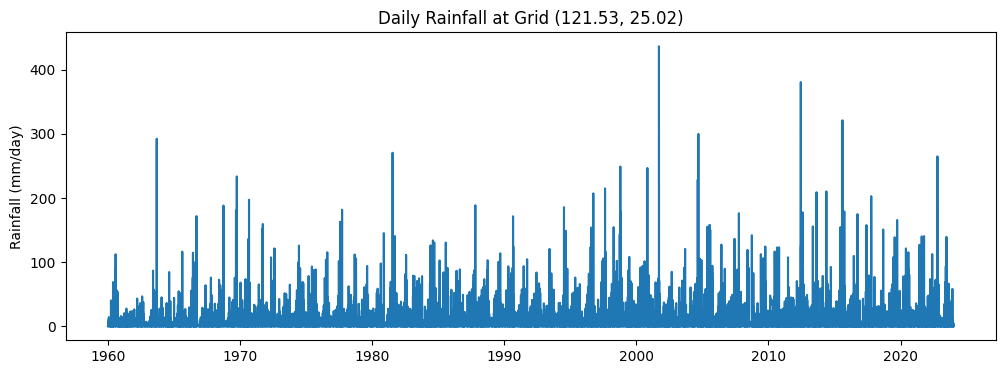

In [9]:
plt.figure(figsize=(12,4))
plt.plot(rain_point["date"], rain_point["rain_mm"])
plt.ylabel("Rainfall (mm/day)")
plt.title("Daily Rainfall at Grid (121.53, 25.02)")
plt.show()

75th percentile threshold = 21.66 mm
95th percentile threshold = 60.88 mm
   year  annual_rain  rainy_days  p75_days  p95_days  p75_amount  p95_amount  \
0  1960    1992.1106         124        26         4   1184.1311    358.1997   
1  1961     490.1402          73         4         0    100.8582      0.0000   
2  1962     630.3020          57         8         0    269.3796      0.0000   
3  1963    1418.2602          74        13         3    897.3091    550.6618   
4  1964     959.6387          98        10         1    379.1085     84.5707   

   p75_ratio  p95_ratio  p75_day_ratio  p95_day_ratio  
0  59.441032  17.980914      20.967742       3.225806  
1  20.577418   0.000000       5.479452       0.000000  
2  42.738179   0.000000      14.035088       0.000000  
3  63.268299  38.826571      17.567568       4.054054  
4  39.505337   8.812765      10.204082       1.020408  
已輸出：/Users/stevechiao/Desktop/程式作業/115_03/觀測_日資料_臺北市_降雨量/Taipei_point_P75_P95_daily_rainfall_indices.csv


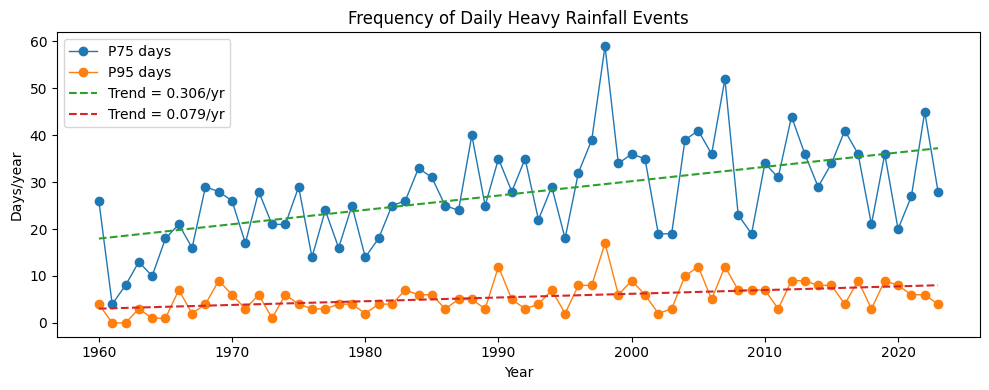

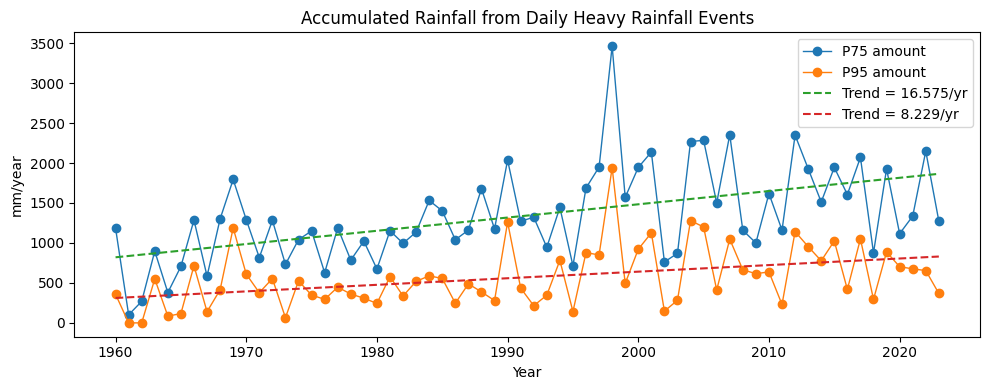

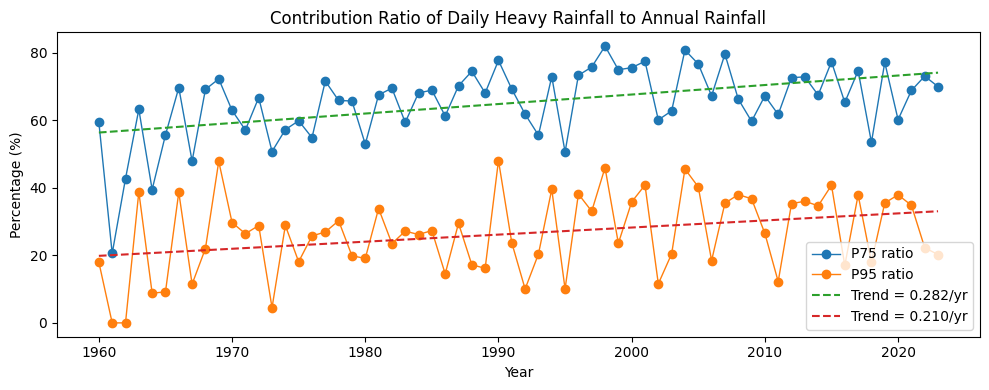

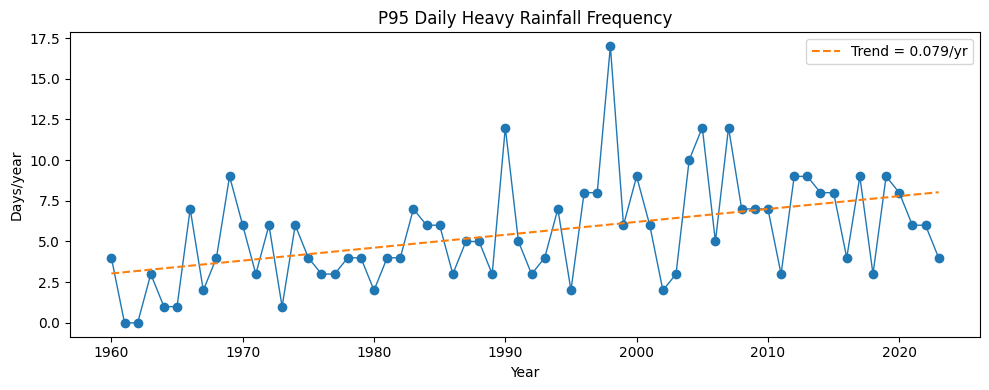

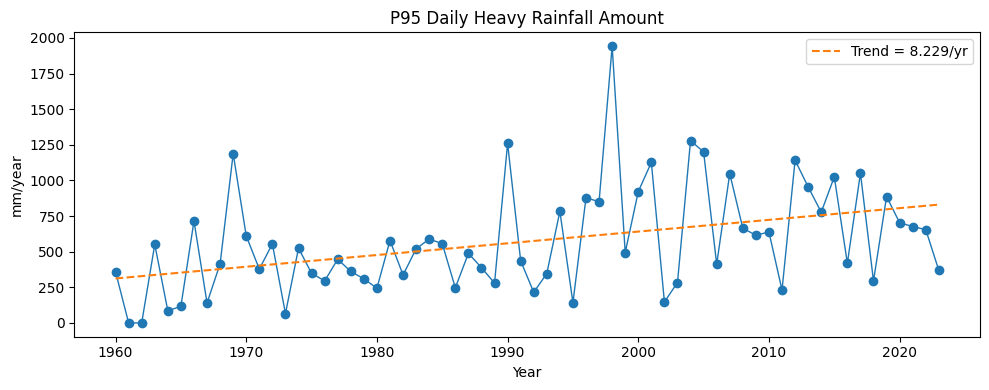

In [20]:
# =========================================
# 3. 只取 wet days (>= 1 mm)
# =========================================
wet = rain_point[rain_point["rain_mm"] >= 1].copy()

# 計算單日降雨的 75% 與 95% 百分位門檻
p75 = wet["rain_mm"].quantile(0.75)
p95 = wet["rain_mm"].quantile(0.95)

print(f"75th percentile threshold = {p75:.2f} mm")
print(f"95th percentile threshold = {p95:.2f} mm")

# =========================================
# 4. 計算每年指標
# =========================================
# 年總雨量
annual_total = rain_point.groupby("year")["rain_mm"].sum().reset_index(name="annual_rain")

# 雨日數（>=1 mm）
rainy_days = rain_point.groupby("year")["rain_mm"].apply(
    lambda x: (x >= 1).sum()
).reset_index(name="rainy_days")

# P75 / P95 發生日數
p75_days = rain_point.groupby("year")["rain_mm"].apply(
    lambda x: (x >= p75).sum()
).reset_index(name="p75_days")

p95_days = rain_point.groupby("year")["rain_mm"].apply(
    lambda x: (x >= p95).sum()
).reset_index(name="p95_days")

# P75 / P95 累積雨量
p75_amount = rain_point.groupby("year")["rain_mm"].apply(
    lambda x: x[x >= p75].sum()
).reset_index(name="p75_amount")

p95_amount = rain_point.groupby("year")["rain_mm"].apply(
    lambda x: x[x >= p95].sum()
).reset_index(name="p95_amount")

# =========================================
# 5. 計算占全年總雨量比例
# =========================================
# =========================================
# 5. 合併成 annual_stats
# =========================================
annual_stats = annual_total.merge(rainy_days, on="year", how="left")
annual_stats = annual_stats.merge(p75_days, on="year", how="left")
annual_stats = annual_stats.merge(p95_days, on="year", how="left")
annual_stats = annual_stats.merge(p75_amount, on="year", how="left")
annual_stats = annual_stats.merge(p95_amount, on="year", how="left")

# =========================================
# 6. 計算比例
# =========================================
annual_stats["p75_ratio"] = annual_stats["p75_amount"] / annual_stats["annual_rain"] * 100
annual_stats["p95_ratio"] = annual_stats["p95_amount"] / annual_stats["annual_rain"] * 100

annual_stats["p75_day_ratio"] = annual_stats["p75_days"] / annual_stats["rainy_days"] * 100
annual_stats["p95_day_ratio"] = annual_stats["p95_days"] / annual_stats["rainy_days"] * 100

print(annual_stats.head())

# =========================================
# 6. 輸出結果
# =========================================
output_dir = "/Users/stevechiao/Desktop/程式作業/115_03/觀測_日資料_臺北市_降雨量"
output_csv = os.path.join(output_dir, "Taipei_point_P75_P95_daily_rainfall_indices.csv")

annual_stats.to_csv(output_csv, index=False, encoding="utf-8-sig")
print(f"已輸出：{output_csv}")

# =========================================
# 7. 畫圖函式：加線性趨勢線
# =========================================
def add_trend_line(ax, x, y):
    x = np.array(x)
    y = np.array(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x_valid = x[mask]
    y_valid = y[mask]

    if len(x_valid) > 1:
        coef = np.polyfit(x_valid, y_valid, 1)
        trend = np.poly1d(coef)
        ax.plot(x_valid, trend(x_valid), linestyle="--", linewidth=1.5,
                label=f"Trend = {coef[0]:.3f}/yr")
        ax.legend()

# =========================================
# 8. 畫圖 1：P75 / P95 發生日數
# =========================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p75_days"], marker="o", linewidth=1, label="P75 days")
ax.plot(annual_stats["year"], annual_stats["p95_days"], marker="o", linewidth=1, label="P95 days")
ax.set_title("Frequency of Daily Heavy Rainfall Events")
ax.set_xlabel("Year")
ax.set_ylabel("Days/year")
ax.legend()
add_trend_line(ax, annual_stats["year"], annual_stats["p75_days"])
add_trend_line(ax, annual_stats["year"], annual_stats["p95_days"])
plt.tight_layout()
plt.savefig("Daxue＿Frequency of Daily Heavy Rainfall Eventst.png", dpi=300)
plt.show()

# =========================================
# 9. 畫圖 2：P75 / P95 累積雨量
# =========================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p75_amount"], marker="o", linewidth=1, label="P75 amount")
ax.plot(annual_stats["year"], annual_stats["p95_amount"], marker="o", linewidth=1, label="P95 amount")
ax.set_title("Accumulated Rainfall from Daily Heavy Rainfall Events")
ax.set_xlabel("Year")
ax.set_ylabel("mm/year")
ax.legend()
add_trend_line(ax, annual_stats["year"], annual_stats["p75_amount"])
add_trend_line(ax, annual_stats["year"], annual_stats["p95_amount"])
plt.tight_layout()
plt.savefig("Daxue＿Accumulated Rainfall from Daily Heavy Rainfall Events.png", dpi=300)
plt.show()

# =========================================
# 10. 畫圖 3：P75 / P95 占全年總雨量比例
# =========================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p75_ratio"], marker="o", linewidth=1, label="P75 ratio")
ax.plot(annual_stats["year"], annual_stats["p95_ratio"], marker="o", linewidth=1, label="P95 ratio")
ax.set_title("Contribution Ratio of Daily Heavy Rainfall to Annual Rainfall")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.legend()
add_trend_line(ax, annual_stats["year"], annual_stats["p75_ratio"])
add_trend_line(ax, annual_stats["year"], annual_stats["p95_ratio"])
plt.tight_layout()
plt.savefig("Daxue＿Contribution Ratio of Daily Heavy Rainfall to Annual Rainfall.png", dpi=300)
plt.show()

# =========================================
# 11. 畫圖 4：單獨看 P95 發生日數與累積雨量
# =========================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p95_days"], marker="o", linewidth=1)
ax.set_title("P95 Daily Heavy Rainfall Frequency")
ax.set_xlabel("Year")
ax.set_ylabel("Days/year")
add_trend_line(ax, annual_stats["year"], annual_stats["p95_days"])
plt.tight_layout()
plt.savefig("Daxue＿P95 Daily Heavy Rainfall Frequency.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p95_amount"], marker="o", linewidth=1)
ax.set_title("P95 Daily Heavy Rainfall Amount")
ax.set_xlabel("Year")
ax.set_ylabel("mm/year")
add_trend_line(ax, annual_stats["year"], annual_stats["p95_amount"])
plt.tight_layout()
plt.savefig("Daxue＿P95 Daily Heavy Rainfall Amount.png", dpi=300)
plt.show()

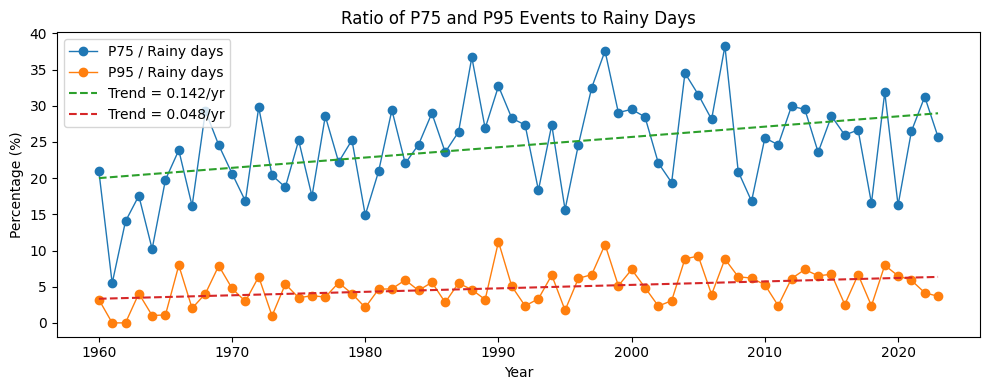

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_stats["year"], annual_stats["p75_day_ratio"], marker="o", linewidth=1, label="P75 / Rainy days")
ax.plot(annual_stats["year"], annual_stats["p95_day_ratio"], marker="o", linewidth=1, label="P95 / Rainy days")
ax.set_title("Ratio of P75 and P95 Events to Rainy Days")
ax.set_xlabel("Year")
ax.set_ylabel("Percentage (%)")
ax.legend()
add_trend_line(ax, annual_stats["year"], annual_stats["p75_day_ratio"])
add_trend_line(ax, annual_stats["year"], annual_stats["p95_day_ratio"])
plt.tight_layout()
plt.savefig("Daxue＿Ratio of P75 and P95 Events to Rainy Days.png", dpi=300)
plt.show()